## Matrix Multiplication with S3 Persistence

A compact end-to-end example that computes a matrix product and stores the result in AWS S3 using LAILA.

### What this notebook does
- Generate two random matrices and compute `C = A @ B`
- Wrap `C` as a LAILA entry (`laila.constant`) to get a global ID
- Persist the entry to S3 via `S3Pool` (`memorize`)
- Retrieve the entry from S3 (`remember`)
- Remove the stored object (`forget`) for cleanup

### Credentials
This notebook reads AWS credentials from:
`laila.args`


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/ubuntu/")

In [3]:
import laila
laila.read_args("/home/ubuntu/laila/vault/dev_secrets.toml")
import time
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from laila.pool import S3Pool

required = ["AWS_BUCKET_NAME", "AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_REGION"]
missing = [name for name in required if getattr(laila.args, name, None) is None]
if missing:
    raise RuntimeError(f"Missing laila.args values: {', '.join(missing)}")

s3_pool = S3Pool(
    bucket_name=laila.args.AWS_BUCKET_NAME,
    access_key_id=laila.args.AWS_ACCESS_KEY_ID,
    secret_access_key=laila.args.AWS_SECRET_ACCESS_KEY,
    region_name=laila.args.AWS_REGION,
    nickname="my_s3_pool"
)

In [5]:
laila.add_pool(s3_pool, pool_nickname="my_s3_pool")

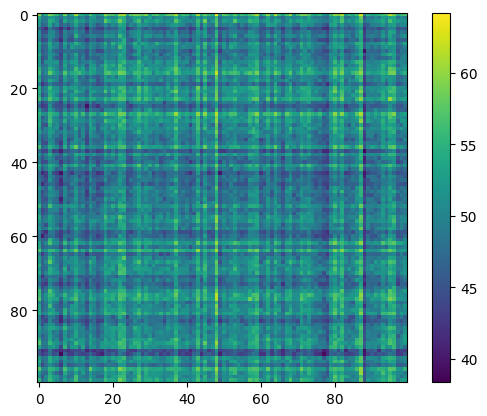

In [6]:
#generate two random matrices and multiply them
A = np.random.rand(100, 200)
B = np.random.rand(200, 100)
C = A @ B

#show a heatmap of the result
plt.imshow(C)
plt.colorbar()
plt.show()


In [7]:
#wrap the result in a constant to get a global id
wrapped_C = laila.constant(data=C, nickname = "my_important_result")
#store the result in S3
future_memorize = laila.memorize(wrapped_C, pool_nickname="my_s3_pool")
#print the status of the future
print ("Before waiting: ", future_memorize.status)
#ensure storage is complete
future_memorize.wait()
#print the status of the future
print ("After waiting: ", future_memorize.status)

Before waiting:  FutureStatus.NOT_STARTED
After waiting:  FutureStatus.FINISHED


In [8]:
print (wrapped_C.global_id)
print (s3_pool.global_id)

LAILA:ENTRY:GLOBAL_ID:f079838f-2632-5435-ab01-55b271b0e3b6
LAILA:POOL:GLOBAL_ID:6b4ae732-09c2-5848-b33a-41475e8221aa


In [9]:
C_global_id = wrapped_C.global_id
#Reference the wrapped_C and C objects to allow garbage collection, they are cleared from memory. 
wrapped_C = None
C = None

In [10]:
print (C_global_id)

LAILA:ENTRY:GLOBAL_ID:f079838f-2632-5435-ab01-55b271b0e3b6


In [11]:
#retrieve the result from S3
future_remember = laila.remember(
    nickname = "my_important_result", 
    pool_nickname="my_s3_pool"
)
#ensure retrieval is complete
future_remember.wait()
#get the result - returned as a laila entry 
recovered_C_entry = future_remember.result
print (recovered_C_entry.global_id)
#extract the data from the laila entry
recovered_C = recovered_C_entry.data

LAILA:ENTRY:GLOBAL_ID:f079838f-2632-5435-ab01-55b271b0e3b6


In [14]:
print (type(recovered_C))

<class 'numpy.ndarray'>


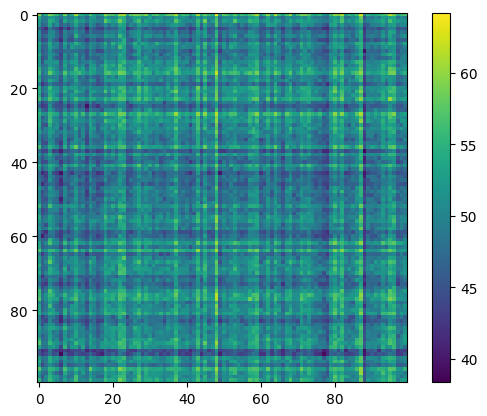

In [12]:
#plot the recovered result
plt.imshow(recovered_C)
plt.colorbar()
plt.show()

In [13]:
#forget the result, C is now deleted from S3
future_forget = laila.forget(C_global_id, pool_nickname="my_s3_pool")
#ensure forgetting is complete
future_forget.wait()
#print the status of the future
print (future_forget.status)


FutureStatus.FINISHED
